In [89]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.pyplot import imread
import os, glob
import xarray as xr
from tqdm import tqdm
import shutil
from scipy.ndimage import label
from scipy.stats import mode
from scipy.ndimage import laplace, sobel
import matplotlib.patches as patches
from scipy.ndimage import binary_fill_holes
from skimage.exposure import rescale_intensity
from skimage.segmentation import random_walker
from skimage.segmentation import flood
from scipy.signal import argrelmax, argrelmin
from scipy.ndimage import binary_fill_holes, binary_dilation
from multiprocessing import Pool
from scipy.signal import savgol_filter
import cmocean as cmo

In [2]:
def load_images(fd):
    files = sorted(glob.glob(fd+'/*.jpg'))
    timestr = [' '.join(f.split('/')[-1].split('.')[0].split('_')) for f in files]
    timestr = np.array([pd.to_datetime(t) for t in timestr], dtype='datetime64[m]')

    dat = np.zeros((len(files), 480, 640))
    for i,f in enumerate(files):
        dat[i] = imread(f)
    
    return timestr,dat

In [3]:
total_mask = np.load('arrs/total_mask.npy')

In [9]:
mask1_files = sorted(glob.glob('arrs/mask1*'))
mask2_files = sorted(glob.glob('arrs/mask2*'))
mask1 = np.zeros((len(mask1_files),*total_mask.shape))
mask2 = np.zeros((len(mask2_files),*total_mask.shape))
for i,(f1, f2) in enumerate(zip(mask1_files, mask2_files)):
    mask1[i] = np.load(f1)
    mask2[i] = np.load(f2)

In [10]:
lake_tot = mask1 + mask2 - mask1*mask2
lf = lake_tot.sum(axis=(1,2))/total_mask.sum()
l1f = mask1.sum(axis=(1,2))/total_mask.sum()

In [79]:
times = [pd.to_datetime(f.split('_')[-1].split('.')[0]) for f in mask1_files]

## Make plot of entire thing

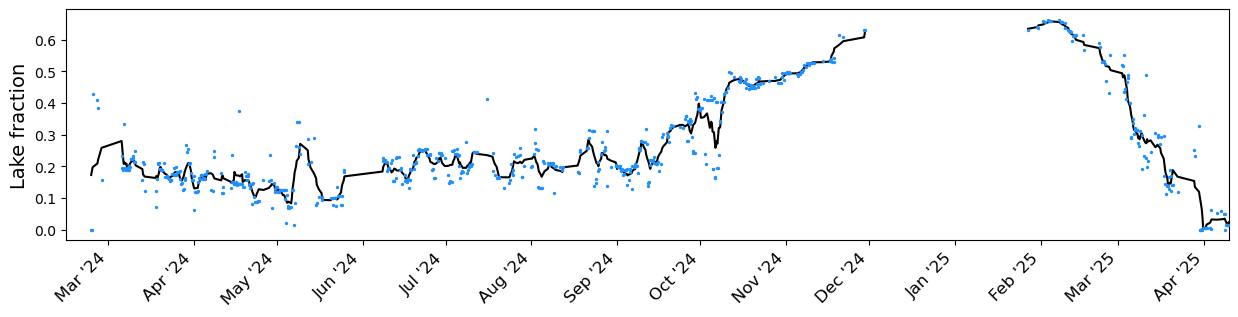

In [72]:
fig, axs = plt.subplots(1,1,figsize=(15,3))

axs.scatter(times, lf,s=2, zorder=10, color='dodgerblue')

smoothed = savgol_filter(lf, 9, 1)
times = np.array(times, dtype='datetime64')
t1 = times < pd.to_datetime('2025-01')
axs.plot(times[t1], smoothed[t1], color='black')
axs.plot(times[~t1], smoothed[~t1], color='black')

axs.set_ylabel('Lake fraction', fontsize=14)

xticks = pd.date_range('2024-02', '2025-04', freq= '1ME') + pd.Timedelta('1d')
labels = [x.strftime('%b \'%y') for x in xticks]

axs.set_xlim(pd.to_datetime('2024-02-15'), pd.to_datetime('2025-04-10'))
axs.set_xticks(xticks, labels, rotation=45, ha='right', fontsize=12)

fig.savefig('lake_size.pdf', dpi=200, bbox_inches='tight')

## All plots, for posterity

In [74]:
def load_images(fd):
    files = sorted(glob.glob(fd+'/*.jpg'))
    timestr = [' '.join(f.split('/')[-1].split('.')[0].split('_')) for f in files]
    timestr = np.array([pd.to_datetime(t) for t in timestr], dtype='datetime64[m]')

    dat = np.zeros((len(files), 480, 640))
    for i,f in enumerate(files):
        dat[i] = imread(f)
    
    return timestr,dat

In [81]:
scratch_dir = '/pscratch/sd/d/dcarrel/volcano_imgs/'
fft_lodir = scratch_dir + '6hourly_lofft'
lorot, lo = load_images(fft_lodir)
lo = xr.DataArray(lo, coords={'time': lorot, 'y': np.arange(480), 'x': np.arange(640)})
loro = lo.rolling({'time':5}, center=True,min_periods=None).max()
loro = loro.sel(time=times)

/tmp/ipykernel_1870990/1178506651.py:4: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  lo = xr.DataArray(lo, coords={'time': lorot, 'y': np.arange(480), 'x': np.arange(640)})


In [83]:
for i,t in tqdm(enumerate(times)):
    fig, axs = plt.subplots(1,2, figsize=(10,5))
    axs[1].scatter(times, lf,s=2, zorder=10, color='dodgerblue')
    axs[1].axvline(x=pd.to_datetime(t), color='black', zorder=0)
    
    axs[0].contour(mask1[i], colors='red', linewidths=1)
    axs[0].contour(mask2[i], colors='orange', linewidths=1)
    axs[0].contour(total_mask, colors='lime', linewidths=1)
    axs[0].imshow(loro.sel(time=t).values, origin='upper')

    fig.savefig(f'plots/{i:03d}.png', bbox_inches='tight')
    plt.close(fig)

664it [03:59,  2.77it/s]


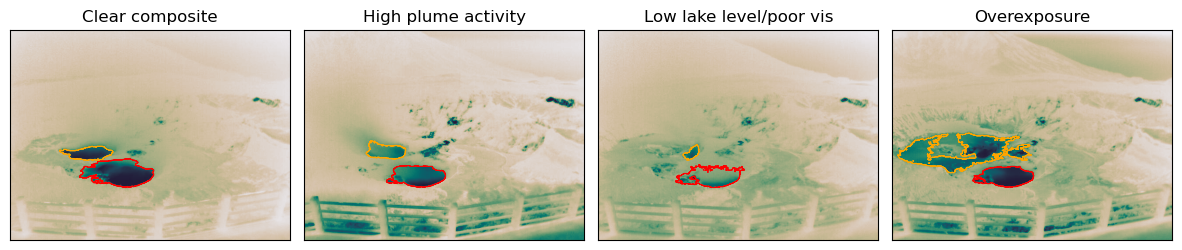

In [105]:
fig, axs = plt.subplots(1,4, figsize=(15,5))
stuff2plot = [250,33,166,116]
labels=['Clear composite','High plume activity','Low lake level/poor vis', 'Overexposure']

for i, ax in enumerate(axs):
    ax = axs[i]
    j = stuff2plot[i]
    m1 = mask1[j]
    m2 = mask2[j]
    ax.contour(m1, colors='red', linewidths=0.5)
    ax.contour(m2, colors='orange', linewidths=0.5)
    ax.imshow(loro.sel(time=times[j]), cmap='cmo.rain')
    ax.set_title(labels[i])
    ax.set_xticks([])
    ax.set_yticks([])

plt.subplots_adjust(wspace=0.05)

fig.savefig('examples.pdf', dpi=300, bbox_inches='tight')

In [ ]:
## good = 33
## full = 250
## really poor job: 166